In [16]:
#since unlike random forest whiocvh is uses decision trees ( which doesnt care about difference in scale of inputs 
# the svm used gemoteric distance in the free 3d space for appropriate e ( epsilon) insensitive tube 
# it is hence nessecary to first standardize all inpuuts 

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
# 1. Load Clean Dataset
df = pd.read_csv("dwsim_surrogate_clean.csv")
# 2. Logit Transform Functions
def logit_trans(purity, eps=1e-5):
    p_clip = np.clip(purity, eps, 1.0 - eps)
    return np.log(p_clip / (1.0 - p_clip))
def inv_logit_trans(y_logit):
    return 1.0 / (1.0 + np.exp(-y_logit))
# 3. Feature Engineering Function
def engineer_features(df_in):
    X = df_in[["Feed temperature", "Feed pressure", "Feed composition", 
              "Number of stages", "Reflux ratio", "Bottoms withdrawal rate", 
              "Molar flow", "Column pressure", "Feed Stage"]].copy()
    
    F = X["Molar flow"]
    B = X["Bottoms withdrawal rate"]
    xF = X["Feed composition"]
    R = X["Reflux ratio"]
    N = X["Number of stages"]
    NF = X["Feed Stage"]
    
    D = np.maximum(F - B, 1e-5)
    X["D_calc"] = D
    X["mass_balance_ratio"] = (F * xF) / D
    X["L_to_V_ratio"] = (R * D) / ((R + 1.0) * D + 1e-5)
    X["V_to_F_ratio"] = ((R + 1.0) * D) / (F + 1e-5)
    X["NF_fraction"] = NF / N
    
    return X
# Engineer Features
X_raw = engineer_features(df)
# Targets
y_dist = df["Distillate purity"]
y_btm = df["Bottom purity"]
y_cond = df["Condensor Duty"]
y_reb = df["Reboiler Duty"]
# Train/Test Split (80% Train, 20% Test)
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
# CRITICAL FOR SVR: Scale Inputs using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_raw.iloc[train_idx])
X_test_scaled = scaler.transform(X_raw.iloc[test_idx])
# -------------------------------------------------------------
# SVR MODEL 1: Distillate Purity (Logit Transformed)
# -------------------------------------------------------------
y_dist_tr_logit = logit_trans(y_dist.iloc[train_idx])
svr_dist = SVR(kernel='rbf', C=50.0, epsilon=0.01, gamma='scale')
svr_dist.fit(X_train_scaled, y_dist_tr_logit)
pred_dist_logit = svr_dist.predict(X_test_scaled)
pred_dist = inv_logit_trans(pred_dist_logit)
r2_dist = r2_score(y_dist.iloc[test_idx], pred_dist)
# -------------------------------------------------------------
# SVR MODEL 2: Bottom Purity (Logit Transformed)
# -------------------------------------------------------------
y_btm_tr_logit = logit_trans(y_btm.iloc[train_idx])
svr_btm = SVR(kernel='rbf', C=50.0, epsilon=0.01, gamma='scale')
svr_btm.fit(X_train_scaled, y_btm_tr_logit)
pred_btm_logit = svr_btm.predict(X_test_scaled)
pred_btm = inv_logit_trans(pred_btm_logit)
r2_btm = r2_score(y_btm.iloc[test_idx], pred_btm)
# -------------------------------------------------------------
# SVR MODEL 3: Condenser Duty (Raw Scale)
# -------------------------------------------------------------
svr_cond = SVR(kernel='rbf', C=100.0, epsilon=0.1, gamma='scale')
svr_cond.fit(X_train_scaled, y_cond.iloc[train_idx])
pred_cond = svr_cond.predict(X_test_scaled)
r2_cond = r2_score(y_cond.iloc[test_idx], pred_cond)
# -------------------------------------------------------------
# SVR MODEL 4: Reboiler Duty (Raw Scale)
# -------------------------------------------------------------
svr_reb = SVR(kernel='rbf', C=100.0, epsilon=0.1, gamma='scale')
svr_reb.fit(X_train_scaled, y_reb.iloc[train_idx])
pred_reb = svr_reb.predict(X_test_scaled)
r2_reb = r2_score(y_reb.iloc[test_idx], pred_reb)
# -------------------------------------------------------------
# PRINT SVR RESULTS SUMMARY
# -------------------------------------------------------------
print("\n================ SVR SURROGATE MODEL R2 SCORES ================")
print(f"1. Distillate Purity R2: {r2_dist:.4f}  | MAE: {mean_absolute_error(y_dist.iloc[test_idx], pred_dist):.6f}")
print(f"2. Bottom Purity R2:     {r2_btm:.4f}  | MAE: {mean_absolute_error(y_btm.iloc[test_idx], pred_btm):.6f}")
print(f"3. Condenser Duty R2:   {r2_cond:.4f}  | MAE: {mean_absolute_error(y_cond.iloc[test_idx], pred_cond):.4f} kW")
print(f"4. Reboiler Duty R2:    {r2_reb:.4f}  | MAE: {mean_absolute_error(y_reb.iloc[test_idx], pred_reb):.4f} kW")
print("================================================================")


================ SVR SURROGATE MODEL R2 SCORES ================
1. Distillate Purity R2: -6.8589  | MAE: 0.006832
2. Bottom Purity R2:     0.1129  | MAE: 0.020441
3. Condenser Duty R2:   0.9881  | MAE: 1.9306 kW
4. Reboiler Duty R2:    0.9897  | MAE: 2.2673 kW


In [19]:
# the massive sudden degradation (-ve) suggest that there is some underlying issue or mistake that am doing which to be 
# wasnt apperent at all untill found 
# the logit transformation make hugee distance between 0.999 and 0.9999 for example which then give wrong predictions 
# so only or distillate purity we improvise and not use logit value instead pulgin the raw values 

In [20]:
# SVR fitted directly on RAW Distillate Purity
svr_raw_dist = SVR(kernel='rbf', C=100.0, epsilon=0.001, gamma='scale')
svr_raw_dist.fit(X_train_scaled, y_dist.iloc[train_idx])
pred_raw_dist = np.clip(svr_raw_dist.predict(X_test_scaled), 0.0, 1.0)
print(f"RAW SVR Distillate Purity R2: {r2_score(y_dist.iloc[test_idx], pred_raw_dist):.4f} | MAE: {mean_absolute_error(y_dist.iloc[test_idx], pred_raw_dist):.6f}")

RAW SVR Distillate Purity R2: 0.9133 | MAE: 0.002373


In [8]:

# Set publication style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

In [9]:
# Set publication style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

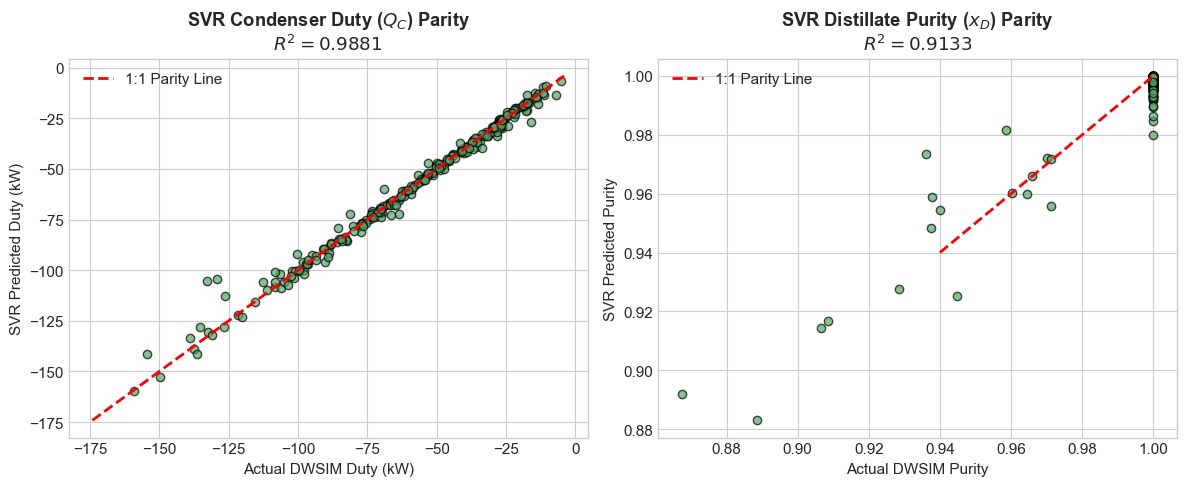

In [23]:
import matplotlib.pyplot as plt
# --- SVR Parity Plots for Energy Duties and Distillate Purity ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# 1. Condenser Duty Parity
min_c, max_c = y_cond.min(), y_cond.max()
ax1.scatter(y_cond.iloc[test_idx], pred_cond, color='#55a868', alpha=0.7, edgecolors='k')
ax1.plot([min_c, max_c], [min_c, max_c], 'r--', lw=2, label='1:1 Parity Line')
ax1.set_title(f'SVR Condenser Duty ($Q_C$) Parity\n$R^2 = {r2_cond:.4f}$', fontweight='bold')
ax1.set_xlabel('Actual DWSIM Duty (kW)')
ax1.set_ylabel('SVR Predicted Duty (kW)')
ax1.legend()
# 2. Distillate Purity Parity
ax2.scatter(y_dist.iloc[test_idx], pred_raw_dist, color='#55a868', alpha=0.7, edgecolors='k')
ax2.plot([0.94, 1.0], [0.94, 1.0], 'r--', lw=2, label='1:1 Parity Line')
ax2.set_title(f'SVR Distillate Purity ($x_D$) Parity\n$R^2 = {0.9133:.4f}$', fontweight='bold')
ax2.set_xlabel('Actual DWSIM Purity')
ax2.set_ylabel('SVR Predicted Purity')
ax2.legend()
plt.tight_layout()
plt.savefig("svr_parity_plots.png", dpi=300)
plt.show()